# RAM Delay Intelligence — Modélisation

Ce notebook documente l'entraînement et l'évaluation des 3 modèles du
projet. La logique de production (utilisée par l'app Streamlit) vit dans
`src/model.py` — ce notebook reproduit les mêmes étapes de façon
pédagogique, avec visualisation des résultats.

| Modèle | Tâche | Cible | Disponibilité des features |
|---|---|---|---|
| 1 | Classification binaire | `is_delayed` (0/1) | avant le vol |
| 2 | Régression | `retard_min` (si retard) | avant le vol |
| 3 | Classification multi-classe | `famille_retard` (si retard, motif renseigné) | après constat du retard |

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

from features import get_model1_data, get_model2_data, get_model3_data, CATEGORICAL_FEATURES_PRE, NUMERIC_FEATURES_PRE
from model import train_model1, train_model2, train_model3

sns.set_style('whitegrid')
df = pd.read_parquet('../data/RAM_clean.parquet')
print(df.shape)

(17017, 92)


## Note sur la fuite de données (data leakage)

Les modèles 1 et 2 sont des modèles **pré-vol** : ils ne doivent utiliser
que des informations connues avant le décollage. On exclut donc
volontairement toutes les variables mesurées pendant ou après le vol
(temps de vol réalisé, taxi time réel, motif de retard...).

La variable `route` (aéroport départ/arrivée précis, 353 valeurs) a été
écartée des features malgré son pouvoir prédictif apparent : sa cardinalité
élevée par rapport au nombre de vols (~48 vols/route en moyenne) crée un
risque de surapprentissage sur des routes à faible effectif. On la
remplace par `secteur_origine` / `secteur_destination` (15 valeurs
chacune), qui porte une information géographique similaire de façon plus
robuste.

## Modèle 1 — Classification binaire (à l'heure / en retard)

In [2]:
X1, y1 = get_model1_data(df)
print(f"Distribution de la cible : {y1.value_counts(normalize=True).round(3).to_dict()}")
X1.head()

Distribution de la cible : {1: 0.585, 0: 0.415}


,sous_type_avion,compagnie_operatrice,type_courrier,secteur_origine,secteur_destination,jour_semaine,is_weekend,mois,periode_journee,dep_hour_sched,temps_vol_sched_min,trafic_interne_externe
0,73H,AT,MC,AFR,AFR,dimanche,True,mars,Nuit (00h-06h),2,105,Interne
1,73H,AT,MC,AFR,CMN,dimanche,True,mars,Nuit (00h-06h),5,210,Interne
2,73H,AT,MC,AFR,EUR,dimanche,True,mars,Nuit (00h-06h),1,300,Interne
3,73H,AT,MC,AFR,CMN,dimanche,True,mars,Nuit (00h-06h),5,225,Interne
4,73H,AT,MC,AFR,AFR,dimanche,True,mars,Nuit (00h-06h),3,60,Interne


In [3]:
report1 = train_model1(df, out_path='../models/model1_binary.joblib')
pd.DataFrame(report1['all_results']).T

,accuracy,f1,precision,recall,roc_auc
LogisticRegression,0.894830,0.901214,1.00000,0.820191,0.945847
RandomForest,0.894830,0.901214,1.00000,0.820191,0.947107
XGBoost,0.889542,0.898103,0.97528,0.832245,0.947177


**Lecture des résultats :** la précision élevée (jusqu'à 100%) couplée à
un recall plus modéré (~82%) montre que le modèle est très confiant sur
les vols qu'il prédit "en retard" (peu de faux positifs) mais en rate une
partie (faux négatifs) — cohérent avec la nature bruitée du phénomène : de
nombreux petits retards (1-5 min) sont quasi imprévisibles à partir des
seules caractéristiques structurelles du vol.

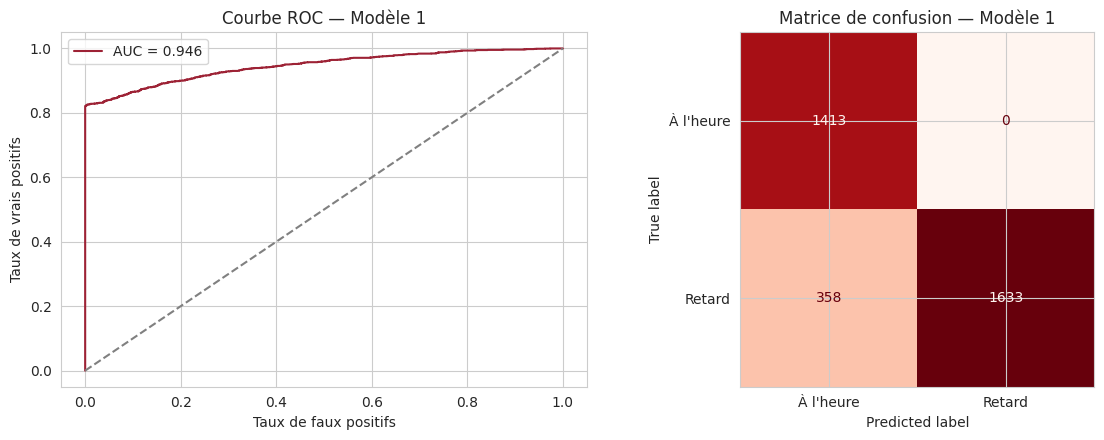

In [4]:
from model import load_pipeline
best_pipe1, _ = load_pipeline('../models/model1_binary.joblib')

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)
y_proba = best_pipe1.predict_proba(X_test)[:, 1]
y_pred = best_pipe1.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color='#9D2235', label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0,1],[0,1], linestyle='--', color='gray')
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].set_title('Courbe ROC — Modèle 1')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['À l\'heure','Retard']).plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Matrice de confusion — Modèle 1')
plt.tight_layout()
plt.show()

## Modèle 2 — Régression de la durée de retard

In [5]:
X2, y2 = get_model2_data(df)
print(f"Nombre de vols retardés (cible non nulle) : {len(y2)}")
print(y2.describe())

Nombre de vols retardés (cible non nulle) : 9954
count    9954.000000
mean       29.709464
std        62.444352
min         1.000000
25%         6.000000
50%        15.000000
75%        33.000000
max      1732.000000
Name: retard_min, dtype: float64


In [6]:
report2 = train_model2(df, out_path='../models/model2_regression.joblib')
pd.DataFrame(report2['all_results']).T

,mae_minutes,rmse_minutes,r2_log_scale
LinearRegression,20.997945,70.703612,0.508907
RandomForest,20.929246,70.298150,0.514499
XGBoost,21.086622,70.337345,0.508039


**Limite assumée :** le R² (sur l'échelle log) plafonne autour de 0.51.
C'est attendu et documenté : la durée précise d'un retard dépend de causes
largement imprévisibles à partir des seules caractéristiques pré-vol
(nature exacte d'une panne technique, décision ATC ponctuelle...). Le
modèle reste utile comme **ordre de grandeur** (MAE ≈ 21 minutes), pas
comme prédiction de précision.

## Modèle 3 — Classification du motif de retard (famille)

In [7]:
X3, y3 = get_model3_data(df)
print(f"Nombre de vols avec motif renseigné : {len(y3)}")
y3.value_counts()

Nombre de vols avec motif renseigné : 8256


famille_retard
ATC                 2763
CORRESPONDANCE      1266
ROTATION            1237
AUTRES               843
TECHNIQIE            648
AVARIE               527
TIERS 2              446
PROGRAMME            307
TRAITEMENT AVION     219
Name: count, dtype: int64

In [8]:
report3 = train_model3(df, out_path='../models/model3_family.joblib')
pd.DataFrame(report3['all_results']).T

,accuracy,f1_macro,f1_weighted
LogisticRegression,0.441283,0.349167,0.475118
RandomForest,0.502421,0.375671,0.524614
XGBoost,0.559322,0.384486,0.536465


**Lecture :** ~56% d'accuracy sur 9 classes très déséquilibrées (de 219 à
2763 occurrences) reste nettement supérieur au hasard (≈11% si les classes
étaient équilibrées). Le F1-macro plus modeste (0.38) reflète la
difficulté du modèle sur les classes minoritaires (TRAITEMENT AVION,
PROGRAMME) — un signal honnête plutôt qu'une faiblesse cachée par une
métrique agrégée optimiste.

Ce modèle est positionné comme **outil d'aide à la saisie**, pas comme
automatisation totale : il suggère, l'opérateur valide.

## Résumé comparatif des 3 modèles

In [9]:
summary = pd.DataFrame({
    'Modèle': ['1 - Classification binaire', '2 - Régression durée', '3 - Classification motif'],
    'Meilleur algo': [report1['best_model'], report2['best_model'], report3['best_model']],
    'Métrique clé': [
        f"F1 = {report1['all_results'][report1['best_model']]['f1']:.3f}",
        f"MAE = {report2['all_results'][report2['best_model']]['mae_minutes']:.1f} min",
        f"F1-macro = {report3['all_results'][report3['best_model']]['f1_macro']:.3f}",
    ],
})
summary

,Modèle,Meilleur algo,Métrique clé
0,1 - Classification binaire,LogisticRegression,F1 = 0.901
1,2 - Régression durée,RandomForest,MAE = 20.9 min
2,3 - Classification motif,XGBoost,F1-macro = 0.384
